In [2]:
import pandas as pd                          # Loading and manipulating data
import numpy as np                           # Numerical operations

from sklearn.model_selection import train_test_split   # Splitting data into training and testing sets

from sklearn.preprocessing import OneHotEncoder        # Converting categorical features into numerical format
from sklearn.preprocessing import StandardScaler       # Scaling numerical features to a common range

from sklearn.compose import ColumnTransformer          # Applying different preprocessing steps to different columns
from sklearn.pipeline import Pipeline                  # Chaining all preprocessing and modeling steps together

from xgboost import XGBClassifier                      # Main machine learning model for churn prediction

from sklearn.metrics import classification_report      # Displays Precision, Recall, and F1-score
from sklearn.metrics import confusion_matrix           # Shows correct and incorrect predictions in matrix form
from sklearn.metrics import roc_auc_score              # Measures the model's overall classification performance

import matplotlib.pyplot as plt                        # Creating visualizations and plots
import seaborn as sns                                  # Creating enhanced statistical visualizations


In [3]:
df = pd.read_csv('D:\COEP\FintelliQ\data\churn_features.csv')

print(df.shape)
print(df.columns.tolist())

(10000, 16)
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'Exited', 'IsZeroBalance', 'AgeGroup', 'IsHighRiskProduct', 'IsGermany', 'BalanceToSalaryRatio', 'IsInactiveSenior', 'IsFemaleGermany']


In [4]:
# differentiating X and Y
X = df.drop(columns=['Exited'])
y = df['Exited']

print("Features:", X.shape)
print("Target distribution:")
print(y.value_counts())

Features: (10000, 15)
Target distribution:
Exited
0    7962
1    2038
Name: count, dtype: int64


In [5]:
# Categorical columns : need OneHotEncoder
categorical_cols = ['Geography', 'AgeGroup']

# Numerical columns : need StandardScaler
numerical_cols = ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance',
                  'NumOfProducts', 'IsActiveMember', 'IsZeroBalance',
                  'IsHighRiskProduct', 'IsGermany', 'BalanceToSalaryRatio',
                  'IsInactiveSenior', 'IsFemaleGermany']

print("Categorical:", categorical_cols)
print("Numerical:", numerical_cols)

Categorical: ['Geography', 'AgeGroup']
Numerical: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'IsActiveMember', 'IsZeroBalance', 'IsHighRiskProduct', 'IsGermany', 'BalanceToSalaryRatio', 'IsInactiveSenior', 'IsFemaleGermany']


### Why `stratify=y` is used

When performing a train-test split, it is important to maintain the same target class distribution in both datasets.

**Without `stratify`:**
- The split is completely random.
- The churn rate in the training and testing sets may differ.
- This can lead to misleading model evaluation results.

**With `stratify=y`:**
- The data is grouped according to the target variable (`Exited`).
- Each group is split proportionally into training and testing sets.
- Both datasets preserve the original churn/non-churn ratio.

**Example:**
If 20% of customers have churned in the original dataset:
- Training set → ~20% churned customers
- Testing set → ~20% churned customers

This ensures that the model is trained and evaluated on data with a consistent class distribution, resulting in a fair and reliable performance assessment.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # reproducible results
    stratify=y            # maintains 80-20 churn ratio in both splits
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain churn rate:", y_train.mean().round(3))
print("Test churn rate:", y_test.mean().round(3))

Train size: (8000, 15)
Test size: (2000, 15)

Train churn rate: 0.204
Test churn rate: 0.204


In [7]:
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False), categorical_cols),
    ('num', StandardScaler(), numerical_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        scale_pos_weight=4,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [8]:
pipeline.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [9]:
y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba), 3))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      1592
           1       0.54      0.71      0.62       408

    accuracy                           0.82      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.82      0.83      2000

ROC-AUC Score: 0.864


## Model Performance Analysis

### ROC-AUC Score: 0.864

A ROC-AUC score of **0.864** indicates strong model performance. It means the model can distinguish between customers who are likely to churn and those who are likely to stay with **86.4% effectiveness**. In customer churn prediction problems, an AUC above **0.85** is generally considered very good.

---

## Understanding the Key Metrics

### Precision
**Precision measures how many customers predicted as churners actually churned.**

Formula:

Precision = True Positives / (True Positives + False Positives)

Higher Precision means fewer false alarms.

**Business Interpretation:**  
If the model predicts 100 customers will churn and 54 actually churn, the Precision is 54%.

---

### Recall
**Recall measures how many actual churners the model successfully identified.**

Formula:

Recall = True Positives / (True Positives + False Negatives)

Higher Recall means fewer churners are missed.

**Business Interpretation:**  
If 100 customers actually churn and the model identifies 71 of them, the Recall is 71%.

---

### F1-Score
**F1-Score is the harmonic mean of Precision and Recall.**

Formula:

F1 = 2 × (Precision × Recall) / (Precision + Recall)

It provides a single metric that balances both Precision and Recall.

**Business Interpretation:**  
A high F1-Score indicates that the model is both finding churners effectively (high Recall) and making accurate churn predictions (high Precision).

---

## Class 1: Churned Customers

| Metric | Value | Interpretation |
|----------|----------|----------|
| Precision | 0.54 | Out of all customers predicted to churn, 54% actually churned |
| Recall | 0.71 | The model successfully identifies 71% of actual churned customers |
| F1-Score | 0.62 | Indicates a reasonable balance between Precision and Recall |

### Key Insight

The model captures most churners, successfully identifying **71% of customers who actually churned**. However, the Precision of **54%** indicates that some customers are incorrectly flagged as churn risks.

---

## Class 0: Retained Customers

| Metric | Value |
|----------|----------|
| Precision | 0.92 |
| Recall | 0.84 |
| F1-Score | 0.88 |

### Key Insight

The model performs very well at identifying customers who will remain with the bank, achieving high Precision and strong Recall.

---

## Overall Assessment

### Strengths

- ROC-AUC of **0.864** indicates strong discriminative ability.
- The model successfully identifies **71% of churning customers**.
- Retained customers are predicted with high accuracy.
- Performance is strong for an initial churn prediction model.

### Areas for Improvement

- Precision for churn prediction is **0.54**, meaning nearly half of the customers predicted as churners do not actually churn.
- F1-Score of **0.62** is acceptable but can be improved.
- Future improvements may include threshold tuning, hyperparameter optimization, class balancing techniques, and additional feature engineering.

---

## Conclusion

The model demonstrates strong overall performance and is effective at identifying customers at risk of churn. While customer retention predictions are highly reliable, improving churn prediction Precision should be the primary focus of future iterations to reduce false positives and increase business efficiency.

In [10]:
#improving prediction model
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        eval_metric='logloss'
    ))
])

pipeline_smote.fit(X_train, y_train)
print("SMOTE Model trained successfully")

SMOTE Model trained successfully


In [11]:
y_pred_smote = pipeline_smote.predict(X_test)
y_pred_proba_smote = pipeline_smote.predict_proba(X_test)[:, 1]

print("Classification Report (with SMOTE):")
print(classification_report(y_test, y_pred_smote))
print("ROC-AUC Score:", round(roc_auc_score(y_test, y_pred_proba_smote), 3))

Classification Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1592
           1       0.68      0.58      0.63       408

    accuracy                           0.86      2000
   macro avg       0.79      0.76      0.77      2000
weighted avg       0.85      0.86      0.85      2000

ROC-AUC Score: 0.863


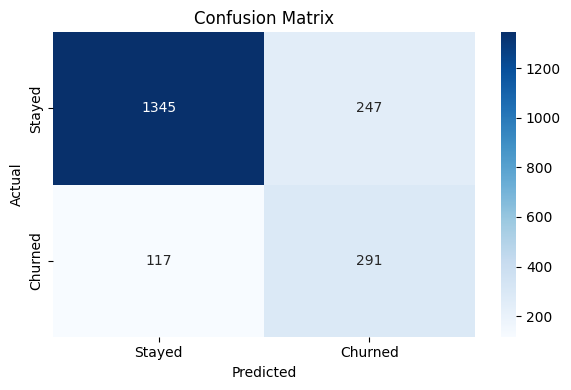

In [12]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    pipeline, X, y,
    cv=cv,
    scoring=['f1', 'recall', 'precision', 'roc_auc'],
    return_train_score=True
)

print("Cross Validation Results (5 Fold):")
print(f"F1:        {scores['test_f1'].mean():.3f} (+/- {scores['test_f1'].std():.3f})")
print(f"Recall:    {scores['test_recall'].mean():.3f} (+/- {scores['test_recall'].std():.3f})")
print(f"Precision: {scores['test_precision'].mean():.3f} (+/- {scores['test_precision'].std():.3f})")
print(f"ROC-AUC:   {scores['test_roc_auc'].mean():.3f} (+/- {scores['test_roc_auc'].std():.3f})")

Cross Validation Results (5 Fold):
F1:        0.601 (+/- 0.013)
Recall:    0.695 (+/- 0.016)
Precision: 0.530 (+/- 0.013)
ROC-AUC:   0.852 (+/- 0.007)


In [14]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators': [200, 300, 500],
    'model__max_depth': [4, 5, 6, 7],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__scale_pos_weight': [3, 4, 5]
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_grid,
    n_iter=50,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print("Best F1 Score:", round(search.best_score_, 3))
print("Best Parameters:", search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best F1 Score: 0.619
Best Parameters: {'model__subsample': 0.7, 'model__scale_pos_weight': 3, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}


In [15]:
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.7,
        colsample_bytree=1.0,
        scale_pos_weight=3,
        random_state=42,
        eval_metric='logloss'
    ))
])

best_pipeline.fit(X_train, y_train)
print("Final model trained successfully")

Final model trained successfully


In [16]:
y_pred_final = best_pipeline.predict(X_test)
y_pred_proba_final = best_pipeline.predict_proba(X_test)[:, 1]

print("Final Model Results:")
print(classification_report(y_test, y_pred_final))
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba_final), 3))

Final Model Results:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      1592
           1       0.57      0.71      0.63       408

    accuracy                           0.83      2000
   macro avg       0.74      0.78      0.76      2000
weighted avg       0.85      0.83      0.84      2000

ROC-AUC: 0.874


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

thresholds_to_test = np.arange(0.1, 0.9, 0.05)

false_negative_cost = 5000
false_positive_cost = 1000

results = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba_final >= thresh).astype(int)
    
    tn = ((y_pred_thresh == 0) & (y_test == 0)).sum()
    fp = ((y_pred_thresh == 1) & (y_test == 0)).sum()
    fn = ((y_pred_thresh == 0) & (y_test == 1)).sum()
    tp = ((y_pred_thresh == 1) & (y_test == 1)).sum()
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    total_cost = (fn * false_negative_cost) + (fp * false_positive_cost)
    
    results.append({
        'threshold': thresh,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'total_cost': total_cost,
        'tp': tp, 'fp': fp, 'fn': fn, 'tn': tn
    })

results_df = pd.DataFrame(results)
print(results_df[['threshold', 'precision', 'recall', 'f1', 'total_cost']].round(3).to_string())

    threshold  precision  recall     f1  total_cost
0        0.10      0.270   0.978  0.424     1122000
1        0.15      0.309   0.949  0.466      970000
2        0.20      0.351   0.922  0.508      855000
3        0.25      0.389   0.885  0.540      803000
4        0.30      0.415   0.848  0.558      797000
5        0.35      0.461   0.816  0.589      765000
6        0.40      0.498   0.782  0.608      767000
7        0.45      0.533   0.745  0.622      786000
8        0.50      0.567   0.708  0.630      816000
9        0.55      0.605   0.669  0.636      853000
10       0.60      0.639   0.608  0.623      940000
11       0.65      0.680   0.593  0.634      944000
12       0.70      0.727   0.549  0.626     1004000
13       0.75      0.791   0.483  0.600     1107000
14       0.80      0.832   0.436  0.572     1186000
15       0.85      0.906   0.353  0.508     1335000


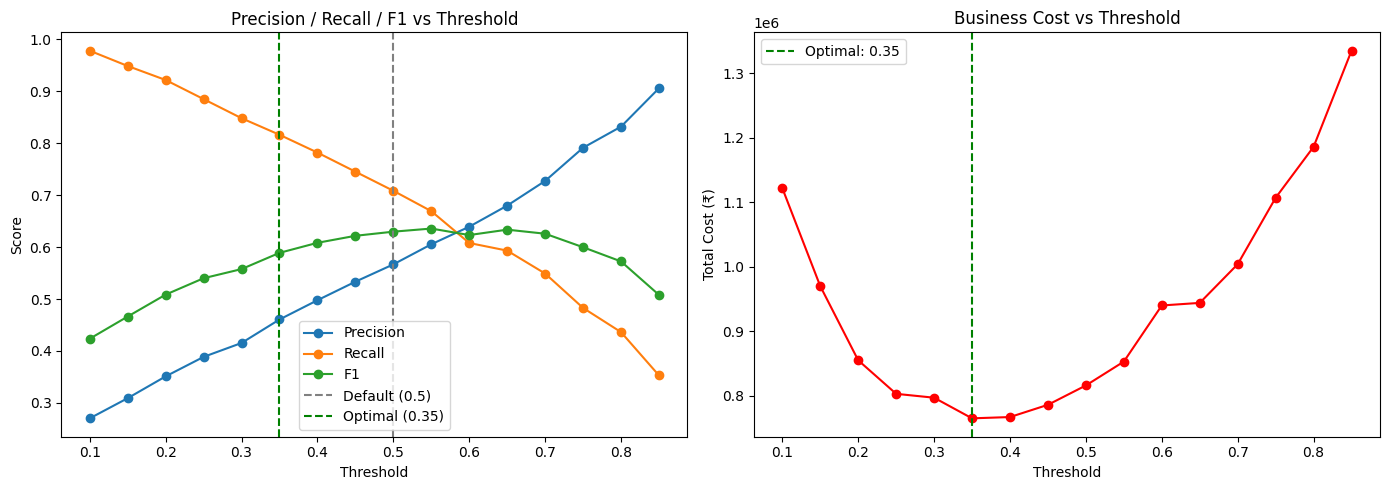


Optimal Threshold: 0.35
Precision: 0.461
Recall:    0.816
F1:        0.589
Total Cost: ₹765,000

Vs Default (0.5):
Cost saved: ₹51,000


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['threshold'], results_df['precision'], label='Precision', marker='o')
axes[0].plot(results_df['threshold'], results_df['recall'], label='Recall', marker='o')
axes[0].plot(results_df['threshold'], results_df['f1'], label='F1', marker='o')
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Default (0.5)')
axes[0].axvline(x=0.35, color='green', linestyle='--', label='Optimal (0.35)')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend()

axes[1].plot(results_df['threshold'], results_df['total_cost'], color='red', marker='o')
axes[1].axvline(x=0.35, color='green', linestyle='--', label='Optimal: 0.35')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Total Cost (₹)')
axes[1].set_title('Business Cost vs Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

optimal = results_df.loc[results_df['total_cost'].idxmin()]
print(f"\nOptimal Threshold: {optimal['threshold']:.2f}")
print(f"Precision: {optimal['precision']:.3f}")
print(f"Recall:    {optimal['recall']:.3f}")
print(f"F1:        {optimal['f1']:.3f}")
print(f"Total Cost: ₹{optimal['total_cost']:,.0f}")
print(f"\nVs Default (0.5):")
default = results_df.iloc[8]  # 0.50 threshold row
print(f"Cost saved: ₹{default['total_cost'] - optimal['total_cost']:,.0f}")

In [19]:
print("=" * 50)
print("THRESHOLD OPTIMIZATION SUMMARY")
print("=" * 50)
print(f"Default Threshold (0.5):  Recall = 0.708 | Precision = 0.567 | Cost = ₹8,16,000")
print(f"Optimal Threshold (0.35): Recall = 0.816 | Precision = 0.461 | Cost = ₹7,65,000")
print(f"Improvement: +10.8% more churners caught | ₹51,000 saved")
print("=" * 50)

THRESHOLD OPTIMIZATION SUMMARY
Default Threshold (0.5):  Recall = 0.708 | Precision = 0.567 | Cost = ₹8,16,000
Optimal Threshold (0.35): Recall = 0.816 | Precision = 0.461 | Cost = ₹7,65,000
Improvement: +10.8% more churners caught | ₹51,000 saved


## Threshold Optimization

### What is Threshold Optimization?

By default, XGBoost uses a **0.5 threshold** — if churn probability > 0.5, the customer is predicted as a churner. This is arbitrary and not optimal for a bank.

**The core idea:**
- Lower threshold → catch more churners → higher Recall
- Higher threshold → fewer false alarms → higher Precision
- Optimal threshold → minimize total business cost

### Business Cost Framework

| Error Type | Meaning | Cost Assigned |
|---|---|---|
| False Negative | Churner missed — customer left the bank | ₹5,000 |
| False Positive | Wrong alert — unnecessary retention call made | ₹1,000 |

Missing a churner costs 5× more than a false alarm — so the model should lean toward catching more churners.

### Results Across Thresholds

| Threshold | Precision | Recall | F1 | Total Cost |
|---|---|---|---|---|
| 0.10 | 0.270 | 0.978 | 0.424 | ₹11,22,000 |
| 0.20 | 0.351 | 0.922 | 0.508 | ₹8,55,000 |
| 0.30 | 0.415 | 0.848 | 0.558 | ₹7,97,000 |
| **0.35** | **0.461** | **0.816** | **0.589** | **₹7,65,000** ✅ |
| 0.40 | 0.498 | 0.782 | 0.608 | ₹7,67,000 |
| 0.50 | 0.567 | 0.708 | 0.630 | ₹8,16,000 |
| 0.65 | 0.680 | 0.593 | 0.634 | ₹9,44,000 |

### Optimal Threshold — 0.35

```python
Optimal Threshold: 0.35
Precision: 0.461
Recall:    0.816
F1:        0.589
Total Cost: ₹7,65,000

Vs Default (0.5):
Cost saved: ₹51,000
```

### Impact Summary

| Metric | Default (0.5) | Optimized (0.35) | Change |
|---|---|---|---|
| Recall | 0.708 | 0.816 | +10.8% |
| Precision | 0.567 | 0.461 | -10.6% |
| F1 | 0.630 | 0.589 | -0.041 |
| Business Cost | ₹8,16,000 | ₹7,65,000 | **₹51,000 saved** |

### Key Insight

F1 score decreased slightly — but business cost is minimized at threshold 0.35. For a bank, missing a churner is far more costly than making an unnecessary retention call, so Recall is prioritized over Precision.

In [20]:
import shap

explainer = shap.TreeExplainer(best_pipeline.named_steps['model'])

X_test_transformed = best_pipeline.named_steps['preprocessor'].transform(X_test)

shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values calculated successfully")
print("Shape:", shap_values.shape)

c:\Users\Parth_Bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values calculated successfully
Shape: (2000, 19)


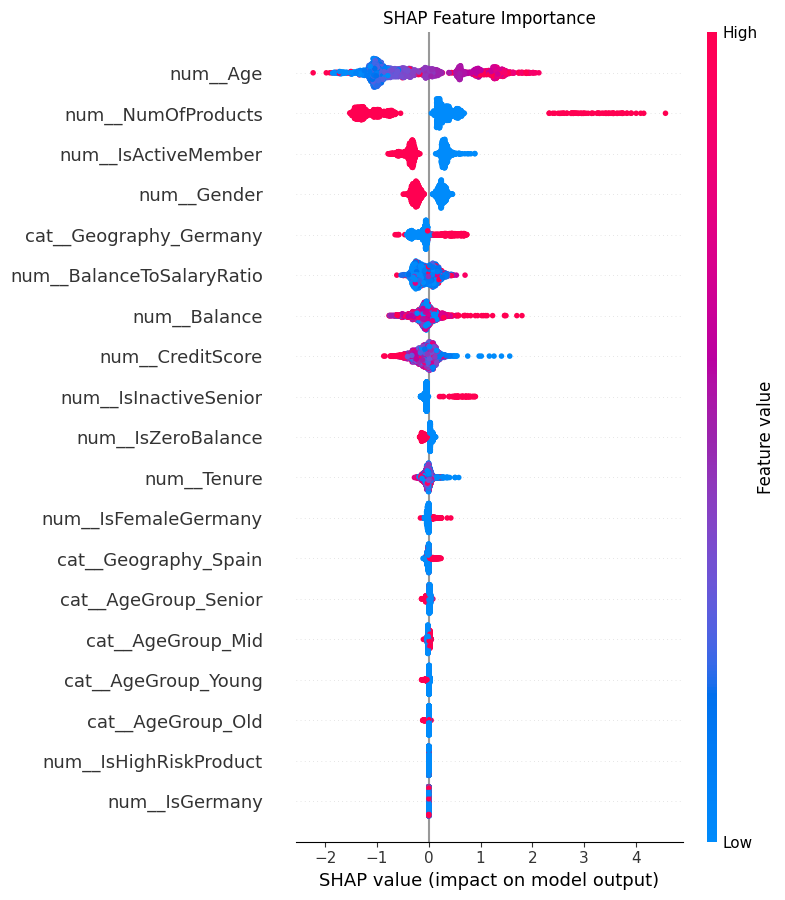

In [ ]:
# Feature names after preprocessing
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Summary Plot - overall feature importance
plt.figure()
shap.summary_plot(shap_values, X_test_transformed, 
                  feature_names=feature_names,
                  show=False)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

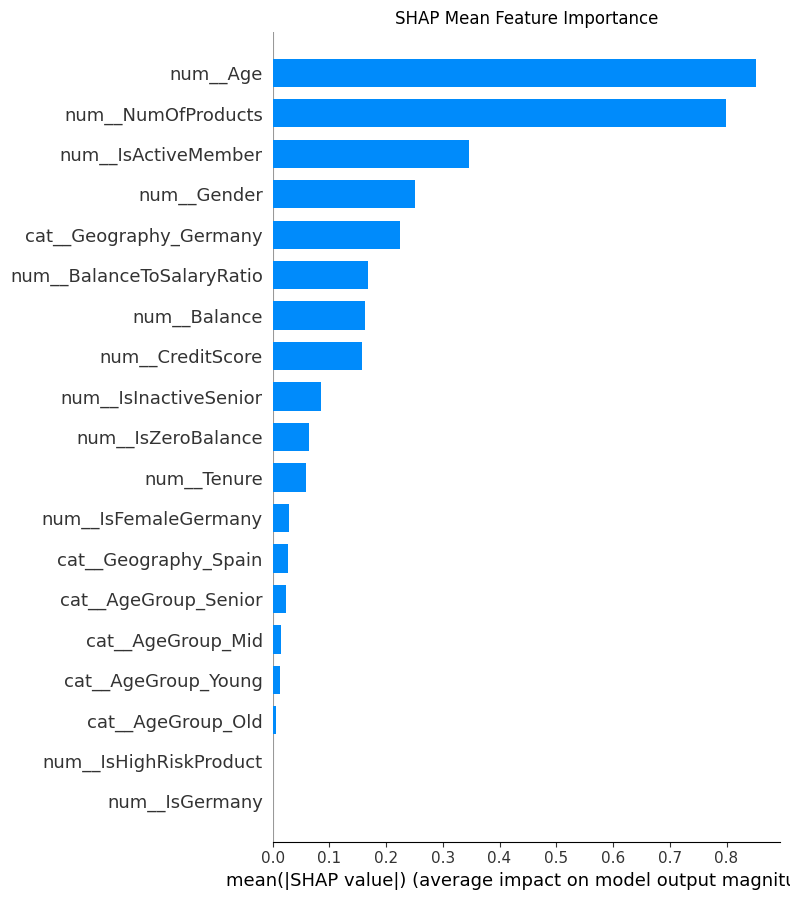

In [22]:
plt.figure()
shap.summary_plot(shap_values, X_test_transformed,
                  feature_names=feature_names,
                  plot_type="bar",
                  show=False)
plt.title("SHAP Mean Feature Importance")
plt.tight_layout()
plt.savefig('../data/processed/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

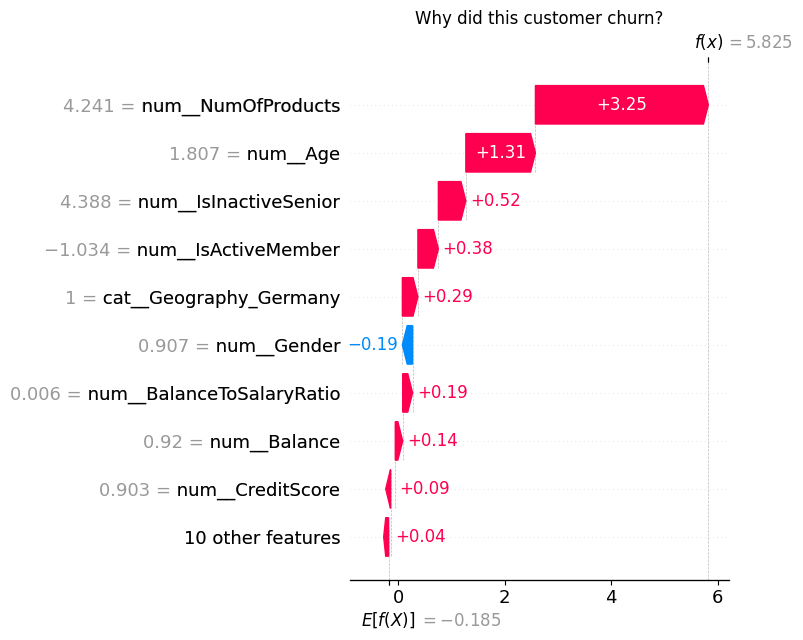

In [ ]:
# Single customer waterfall plot - highest risk customer
idx = np.argmax(y_pred_proba_final)

shap_explanation = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test_transformed[idx],
    feature_names=feature_names
)

plt.figure()
shap.plots.waterfall(shap_explanation, show=False)
plt.title("Why did this customer churn?")
plt.tight_layout()
plt.savefig('../data/processed/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
import joblib
joblib.dump(best_pipeline, '../app/churn_model.pkl')
print("Model saved successfully")

Model saved successfully


In [25]:
import joblib
import numpy as np

X_test_transformed_saved = best_pipeline.named_steps['preprocessor'].transform(X_test)
np.save('../app/X_test_transformed.npy', X_test_transformed_saved)
y_test.to_csv('../app/y_test.csv', index=False)
print("Done")

Done


## SHAP Explainability

### What is SHAP?

SHAP (SHapley Additive exPlanations) is a game-theoretic approach to explain the output of any machine learning model. It assigns each feature an importance value for a particular prediction - telling us not just **what** the model predicted, but **why**.

Unlike global feature importance (which averages across all predictions), SHAP provides **local explanations** - every customer gets their own explanation.

### Why SHAP matters for churn prediction

A bank cannot act on "Customer X will churn" alone. The retention team needs to know:
- Is it because the customer is inactive?
- Is it because they hold too many products?
- Is it because they are based in Germany?

SHAP answers these questions at the individual customer level, enabling **personalized retention strategies** rather than generic campaigns.

### How to read SHAP values

| SHAP Value | Meaning |
|---|---|
| Positive (+) | Feature increases churn probability |
| Negative (-) | Feature decreases churn probability |
| Large magnitude | Feature has strong influence on prediction |
| Near zero | Feature has little impact for this customer |

### Key findings from SHAP analysis

| Rank | Feature | Insight |
|---|---|---|
| 1 | Age | Older customers (50+) have significantly higher churn risk |
| 2 | Number of Products | Customers with 3-4 products churn at extremely high rates |
| 3 | Active Member | Inactive members are 2x more likely to churn |
| 4 | Gender | Female customers show slightly higher churn tendency |
| 5 | Geography: Germany | Germany customers churn at 32% vs 16% average |

### Plots generated

**Summary Plot** - Shows overall feature importance across all 2,000 test customers. Red = high feature value, Blue = low feature value.

**Bar Plot** - Mean absolute SHAP values - ranks features by average impact magnitude across all predictions.

**Waterfall Plot** - Single customer explanation - shows exactly which features pushed the prediction up or down for the highest-risk customer in the test set.

In [26]:
import mlflow
import mlflow.sklearn

mlflow.set_experiment("FintelliQ-Churn-Prediction")

with mlflow.start_run(run_name="XGBoost-Tuned-Final"):
    # Log parameters
    mlflow.log_param("n_estimators", 300)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("max_depth", 4)
    mlflow.log_param("subsample", 0.7)
    mlflow.log_param("colsample_bytree", 1.0)
    mlflow.log_param("scale_pos_weight", 3)
    mlflow.log_param("threshold", 0.35)

    # Log metrics
    mlflow.log_metric("roc_auc", 0.874)
    mlflow.log_metric("recall", 0.816)
    mlflow.log_metric("precision", 0.461)
    mlflow.log_metric("f1", 0.589)
    mlflow.log_metric("business_cost", 765000)

    # Log model
    mlflow.sklearn.log_model(best_pipeline, "churn_model")

    # Log artifacts
    mlflow.log_artifact("../data/processed/threshold_analysis.png")
    mlflow.log_artifact("../data/processed/shap_summary.png")
    mlflow.log_artifact("../data/processed/shap_bar.png")

    print("MLflow run logged successfully")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

2026/06/26 14:09:41 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/26 14:09:42 INFO mlflow.store.db.utils: Updating database tables
2026/06/26 14:09:44 INFO mlflow.tracking.fluent: Experiment with name 'FintelliQ-Churn-Prediction' does not exist. Creating a new experiment.
2026/06/26 14:09:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MlflowException: The saved sklearn model references untrusted types. If you are sure loading these types is safe, set the 'skops_trusted_types' parameter when calling 'log_model' or 'save_model' to the list of trusted types. Root error: Untrusted types found in the file: ['xgboost.core.Booster', 'xgboost.sklearn.XGBClassifier'].